In [52]:
import torchtuples as tt
import matplotlib.pyplot as plt
import numpy as np
from pycox.models import DeepHitSingle
from pycox.evaluation import EvalSurv
from pycox.preprocessing.label_transforms import LabTransDiscreteTime

In [53]:
#from Preprocessing.PreprocessingBrainCancer import prepare_brain_cancer_data as prepare_data
#from Preprocessing.PreprocessingBreastCancer import prepare_breast_cancer_data as prepare_data
#from Preprocessing.PreprocessingLeukemia import prepare_leukemia_data as prepare_data 
#from Preprocessing.PreprocessingLungCancer import prepare_lung_cancer_data as prepare_data
#from Preprocessing.PreprocessingLymphoma import prepare_lymphoma_data as prepare_data
#from Preprocessing.PreprocessingProstateCancer import prepare_prostate_cancer_data as prepare_data
from Preprocessing.PreprocessingSmallIntestineCancer import prepare_small_intestine_cancer_data as prepare_data

x_train, y_train, val_data, x_test, y_test = prepare_data("C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\_SmallIntestineCancerUsaDataset.csv")

Dane wczytane. Rozmiar początkowy: (21347, 24)

Rozmiar X_train: (12615, 67)


In [ ]:
# dyskretyzacja czasu
num_durations = 100

labtrans = LabTransDiscreteTime(num_durations)

y_train_discrete = labtrans.fit_transform(*y_train)
y_val_discrete = labtrans.transform(*val_data[1])

val_data_discrete = (val_data[0], y_val_discrete)

In [ ]:
# definicja architektury sieci
in_features = x_train.shape[1]
num_nodes = [32] 
batch_norm = True
dropout = 0.3 

out_features = labtrans.out_features 

net = tt.practical.MLPVanilla(in_features, num_nodes, out_features, batch_norm, dropout)

In [56]:
# Architektura modelu
optimizer = tt.optim.Adam(weight_decay=0.01) 

# alpha (0.2) - jak mocno model skupia się na prawidłowym rankingu pacjentów względem siebie
# sigma (0.1) - parametr wygładzający (im większy, tym gładsze przejścia)
model = DeepHitSingle(
    net, 
    optimizer, 
    alpha=0.2, 
    sigma=0.1, 
    duration_index=labtrans.cuts
)

model.optimizer.set_lr(0.0001)

Rozpoczęcie uczenia modelu DeepHit...
0:	[0s / 0s],		train_loss: 1.1478,	val_loss: 1.3416
1:	[0s / 0s],		train_loss: 1.2536,	val_loss: 1.1754
2:	[0s / 1s],		train_loss: 0.9314,	val_loss: 1.0844
3:	[0s / 1s],		train_loss: 0.9209,	val_loss: 1.0500
4:	[0s / 1s],		train_loss: 1.0936,	val_loss: 1.0085
5:	[0s / 2s],		train_loss: 0.9834,	val_loss: 0.9791
6:	[0s / 2s],		train_loss: 1.0631,	val_loss: 0.9376
7:	[0s / 2s],		train_loss: 1.0076,	val_loss: 0.9348
8:	[0s / 3s],		train_loss: 1.0110,	val_loss: 0.9256
9:	[0s / 3s],		train_loss: 0.9030,	val_loss: 0.9202
10:	[0s / 3s],		train_loss: 0.8955,	val_loss: 0.9280
11:	[0s / 4s],		train_loss: 0.9335,	val_loss: 0.9248
12:	[0s / 4s],		train_loss: 0.9122,	val_loss: 0.9011
13:	[0s / 5s],		train_loss: 0.8863,	val_loss: 0.9074
14:	[0s / 5s],		train_loss: 0.8894,	val_loss: 0.8946
15:	[0s / 5s],		train_loss: 0.9178,	val_loss: 0.8927
16:	[0s / 6s],		train_loss: 0.8906,	val_loss: 0.8889
17:	[0s / 6s],		train_loss: 0.9231,	val_loss: 0.8838
18:	[0s / 6s],		tr

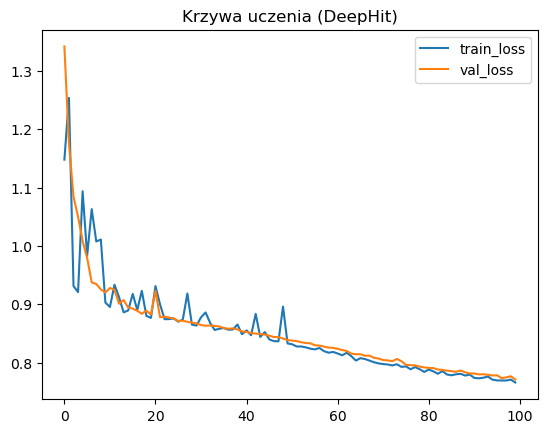

In [57]:
# Uczenie modelu
batch_size = 256
epochs = 100
callbacks = [tt.callbacks.EarlyStopping(patience=10)]

print("Rozpoczęcie uczenia modelu DeepHit...")
log = model.fit(x_train, y_train_discrete, batch_size, epochs, callbacks, val_data=val_data_discrete)

# Wykres funkcji straty
_ = log.plot()
plt.title("Krzywa uczenia (DeepHit)")
plt.show()

In [ ]:
# Ewaluacja na zbiorze testowym

surv_test = model.predict_surv_df(x_test)

ev = EvalSurv(surv_test, y_test[0], y_test[1], censor_surv='km')

# C-index
c_index = ev.concordance_td()
print(f"Time-Dependent Concordance Index (C-index): {c_index:.4f}")

# Integrated Brier Score
time_grid = np.linspace(y_test[0].min(), y_test[0].max(), 100)
integrated_brier_score = ev.integrated_brier_score(time_grid)
print(f"Integrated Brier Score (IBS): {integrated_brier_score:.4f}")

brier_score_time = ev.brier_score(time_grid)

Time-Dependent Concordance Index (C-index): 0.7077
Integrated Brier Score (IBS): 0.2086


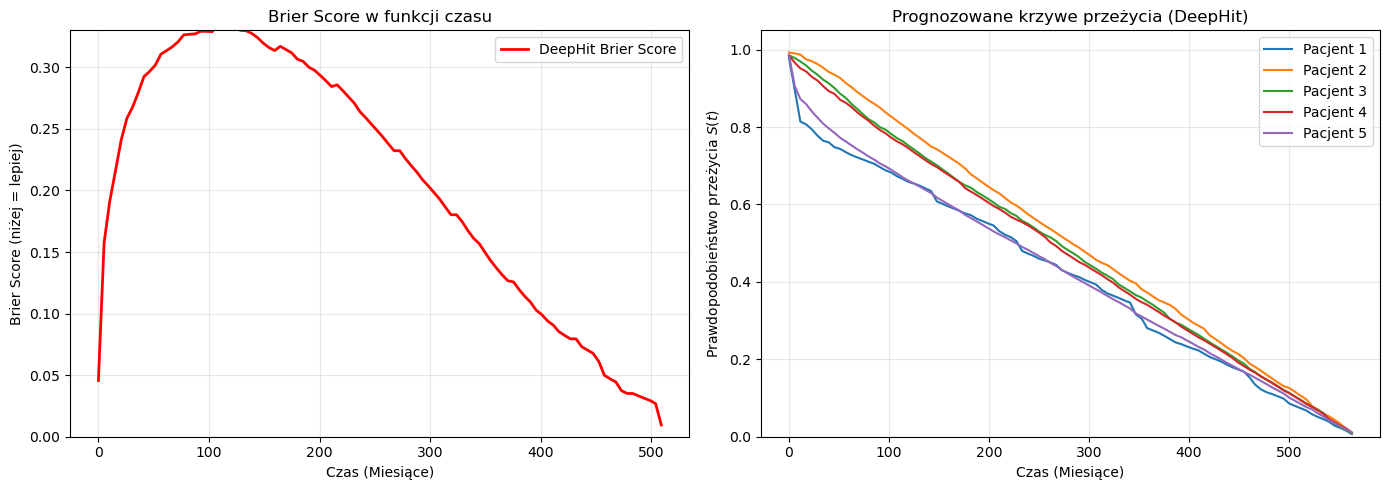

In [ ]:
plt.figure(figsize=(14, 5))

# Brier Score w funkcji czasu
plt.subplot(1, 2, 1)
plt.plot(time_grid, brier_score_time, color='red', linewidth=2, label='DeepHit Brier Score')
plt.title("Brier Score w funkcji czasu")
plt.xlabel("Czas (Miesiące)")
plt.ylabel("Brier Score (niżej = lepiej)")
plt.ylim(0, 0.33)
plt.grid(True, alpha=0.3)
plt.legend()

# Indywidualne krzywe przeżycia dla pierwszych 5 pacjentów
plt.subplot(1, 2, 2)
for i in range(5):
    plt.plot(surv_test.index, surv_test.iloc[:, i], label=f'Pacjent {i+1}')
plt.title("Prognozowane krzywe przeżycia (DeepHit)")
plt.xlabel("Czas (Miesiące)")
plt.ylabel("Prawdopodobieństwo przeżycia $S(t)$")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [1]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device available")

2.7.1+cu118
11.8
True
NVIDIA GeForce GTX 1050 Ti


In [2]:
import scipy.integrate
scipy.integrate.simps = getattr(scipy.integrate, 'simpson', scipy.integrate.trapezoid)

import numpy as np
import pandas as pd
import datetime
import os
import matplotlib.pyplot as plt
import torch
import torchtuples as tt

from pycox.evaluation import EvalSurv
from pycox.models import DeepHitSingle
from pycox.preprocessing.label_transforms import LabTransDiscreteTime

from Preprocessing.PreprocessingBrainCancer import prepare_brain_cancer_data
from Preprocessing.PreprocessingBreastCancer import prepare_breast_cancer_data
from Preprocessing.PreprocessingLeukemia import prepare_leukemia_data
from Preprocessing.PreprocessingLungCancer import prepare_lung_cancer_data
from Preprocessing.PreprocessingLymphoma import prepare_lymphoma_data
from Preprocessing.PreprocessingProstateCancer import prepare_prostate_cancer_data
from Preprocessing.PreprocessingSmallIntestineCancer import prepare_small_intestine_cancer_data

#laptop
#base_path = "C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\"

#komputer dom
base_path = "C:\\Users\\kubap\\OneDrive\\Pulpit\\magisterka ekperymenty\\Datasets\\"

datasets = {
    "Brain Cancer": (prepare_brain_cancer_data, base_path + "_BrainCancerUsaDataset.csv"),
    "Breast Cancer": (prepare_breast_cancer_data, base_path + "_BreastCancerUsaDataset.csv"),
    "Leukemia": (prepare_leukemia_data, base_path + "_LeukemiaUsaDataset.csv"),
    "Lung Cancer": (prepare_lung_cancer_data, base_path + "_LungCancerUsaDataset.csv"),
    "Lymphoma": (prepare_lymphoma_data, base_path + "_LymphomaUsaDataset.csv"),
    "Prostate Cancer": (prepare_prostate_cancer_data, base_path + "_ProstateCancerUsaDataset.csv"),
    "Small Intestine Cancer": (prepare_small_intestine_cancer_data, base_path + "_SmallIntestineCancerUsaDataset.csv")
}

# Osobny folder na wyniki DeepHit
output_folder = "Wykresy_Eksperymenty_DeepHit"
os.makedirs(output_folder, exist_ok=True)

def run_single_experiment(x_train, y_train_discrete, val_data_discrete, x_test, y_test, labtrans):
    in_features = x_train.shape[1]
    out_features = labtrans.out_features 
    
    # klasyczna architektura dla deephit
    net = tt.practical.MLPVanilla(
        in_features=in_features, 
        num_nodes=[32, 32], 
        out_features=out_features,
        batch_norm=True, 
        dropout=0.3
    )
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    optimizer = tt.optim.Adam(weight_decay=0.01)
    
    model = DeepHitSingle(
        net, 
        optimizer, 
        alpha=0.2, 
        sigma=0.1, 
        duration_index=labtrans.cuts,
        device=device
    )
    model.optimizer.set_lr(0.0001)
    
    batch_size = 256
    epochs = 100
    callbacks = [tt.callbacks.EarlyStopping(patience=10)]
    
    # UCZENIE
    log = model.fit(x_train, y_train_discrete, batch_size, epochs, callbacks, val_data=val_data_discrete, verbose=False)
        
    # EWALUACJA
    surv_test = model.predict_surv_df(x_test)
    ev = EvalSurv(surv_test, y_test[0], y_test[1], censor_surv='km')
    c_index = ev.concordance_td()
    
    time_grid = np.linspace(y_test[0].min(), y_test[0].max(), 100)
    ibs = ev.integrated_brier_score(time_grid)
    brier_score_time = ev.brier_score(time_grid)
    
    return c_index, ibs, brier_score_time, log, surv_test, time_grid

# glowna petla i raporty
num_runs = 10
output_filename = "wyniki_eksperymentow_DeepHit.txt"

print(f"START KLASYCZNY DEEPHIT. Wyniki -> {output_filename}, Wykresy -> folder '{output_folder}'")

with open(output_filename, "w", encoding="utf-8") as file:
    file.write(f"RAPORT - KLASYCZNY DEEPHIT\n")
    
    for dataset_name, (prep_func, filepath) in datasets.items():
        print(f"\n[{dataset_name}] Wczytywanie danych")
        file.write(f"\nZBIÓR: {dataset_name}\n")
        
        try:
            x_train, y_train, val_data, x_test, y_test = prep_func(filepath)
            
            # dyskretyzacja czasu przed pętlą
            num_durations = 100
            labtrans = LabTransDiscreteTime(num_durations)
            
            y_train_discrete = labtrans.fit_transform(*y_train)
            y_val_discrete = labtrans.transform(*val_data[1])
            val_data_discrete = (val_data[0], y_val_discrete)
            
        except Exception as e:
            print(f"Błąd podczas wczytywania {dataset_name}: {e}")
            continue

        all_c_indexes, all_ibses = [], []
        all_brier_scores = []
        
        best_c_index = -1
        best_log = None
        best_surv_test = None
        final_time_grid = None

        print(f"Uruchamianie {num_runs} powtórzeń...")
        for i in range(num_runs):
            print(f"   Bieg {i+1}/{num_runs}...", end=" ", flush=True)
            
            c_idx, ibs, brier_st, log, surv_t, t_grid = run_single_experiment(
                x_train, y_train_discrete, val_data_discrete, x_test, y_test, labtrans
            )
            
            all_c_indexes.append(c_idx)
            all_ibses.append(ibs)
            all_brier_scores.append(brier_st)
            
            if c_idx > best_c_index:
                best_c_index = c_idx
                best_log = log
                best_surv_test = surv_t
                final_time_grid = t_grid
                
            print(f"Gotowe (C-index: {c_idx:.4f})")

        # wyniki statystyczne
        mean_c = np.mean(all_c_indexes)
        std_c = np.std(all_c_indexes)
        mean_ibs = np.mean(all_ibses)
        std_ibs = np.std(all_ibses)
        
        avg_brier = np.mean(all_brier_scores, axis=0)

        # zapis do pliku
        file.write(f"C-index (średnia): {mean_c:.4f} +/- {std_c:.4f}\n")
        file.write(f"IBS (średnia):     {mean_ibs:.4f} +/- {std_ibs:.4f}\n")
        file.write(f"Najlepszy C-index: {best_c_index:.4f}\n\n")

        # zapis wykresów
        print(f"Generowanie i zapisywanie uśrednionych wykresów dla {dataset_name}...")
        prefix = f"{output_folder}/{dataset_name.replace(' ', '_')}"

        # wykres1 Brier Score w czasie
        plt.figure(figsize=(8, 5))
        plt.plot(final_time_grid, avg_brier, color='purple', linewidth=2)
        plt.title(f"Średni Brier Score w czasie (Klasyczny DeepHit) - {dataset_name}")
        plt.xlabel("Czas (Miesiące)")
        plt.ylabel("Brier Score")
        plt.ylim(0, 0.3)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{prefix}_IBS_w_czasie.png", dpi=300)
        plt.close()

        # wykres2 krzywa uczenia
        plt.figure(figsize=(8, 5))
        best_log.plot()
        plt.title(f"Krzywa uczenia (Klasyczny DeepHit) - {dataset_name}")
        plt.xlabel("Epoki")
        plt.ylabel("Loss")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{prefix}_Krzywa_Uczenia.png", dpi=300)
        plt.close()

        # wykres3 krzywe przeżycia dla 5 pacjentów
        plt.figure(figsize=(8, 5))
        for i in range(min(5, best_surv_test.shape[1])):
            plt.plot(best_surv_test.index, best_surv_test.iloc[:, i], label=f'Pacjent {i+1}')
        plt.title(f"Przeżycie 5 pacjentów (Klasyczny DeepHit) - {dataset_name}")
        plt.xlabel("Czas (Miesiące)")
        plt.ylabel("Prawdopodobieństwo Przeżycia")
        plt.ylim(0, 1.05)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{prefix}_Przezycie_5_Pacjentow.png", dpi=300)
        plt.close()

print("GOTOWE! Eksperyment dla DeepHit udał sie")

START KLASYCZNY DEEPHIT. Wyniki -> wyniki_eksperymentow_DeepHit.txt, Wykresy -> folder 'Wykresy_Eksperymenty_DeepHit'

[Brain Cancer] Wczytywanie danych
Dane wczytane. Rozmiar początkowy: (66994, 19)

Rozmiar X_train: (39431, 201)
Uruchamianie 10 powtórzeń...
   Bieg 1/10... Gotowe (C-index: 0.7961)
   Bieg 2/10... Gotowe (C-index: 0.7948)
   Bieg 3/10... Gotowe (C-index: 0.7964)
   Bieg 4/10... Gotowe (C-index: 0.7941)
   Bieg 5/10... Gotowe (C-index: 0.7961)
   Bieg 6/10... Gotowe (C-index: 0.7948)
   Bieg 7/10... Gotowe (C-index: 0.7936)
   Bieg 8/10... Gotowe (C-index: 0.7918)
   Bieg 9/10... Gotowe (C-index: 0.7931)
   Bieg 10/10... Gotowe (C-index: 0.7932)
Generowanie i zapisywanie uśrednionych wykresów dla Brain Cancer...

[Breast Cancer] Wczytywanie danych
Dane wczytane. Rozmiar początkowy: (744632, 20)

Rozmiar X_train: (444663, 104)
Uruchamianie 10 powtórzeń...
   Bieg 1/10... Gotowe (C-index: 0.7781)
   Bieg 2/10... Gotowe (C-index: 0.7763)
   Bieg 3/10... Gotowe (C-index: 0

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>